Se puede extender el problema para que el **brazo robótico no solo alcance un punto final, sino que siga una trayectoria óptima**, considerando diferentes criterios. Esto es un problema de **optimización de trayectoria**, y se puede formular de varias maneras.

---

## **1. Formulación del Problema**
El objetivo es encontrar una **secuencia de ángulos** \(\theta_1(t), \theta_2(t)\) a lo largo del tiempo \(t\) para que el efector final del brazo siga una trayectoria deseada \( (x_{\text{deseado}}(t), y_{\text{deseado}}(t)) \).

Dado un **horizonte temporal** \(T\), queremos minimizar un **criterio de optimización**.

### **Criterios de Optimización Posibles**
1. **Minimizar el error de trayectoria**: Reducir la diferencia entre la trayectoria deseada y la real en cada instante \(t\).
2. **Minimizar el consumo energético**: Evitar cambios bruscos en las articulaciones para reducir el esfuerzo.

Ambos criterios pueden combinarse en una única función objetivo con pesos:

$
J = \sum_{t=0}^{T} \left[ w_1 \cdot \text{Error de trayectoria} + w_2 \cdot \text{Esfuerzo muscular} \right]
$

donde \( w_1 \) y \( w_2 \) son pesos ajustables para priorizar precisión o consumo energético.

---

## **2. Datos Necesarios**
Para definir el problema necesitamos:

- **Datos de la trayectoria deseada**:
  - Lista de posiciones \((x_{\text{deseado}}, y_{\text{deseado}})\) en función del tiempo \(t\).
  - Velocidades deseadas \((\dot{x}_{\text{deseado}}, \dot{y}_{\text{deseado}})\) si optimizamos suavidad.

- **Datos del brazo robótico**:
  - Longitudes de los eslabones \(L_1, L_2\).
  - Límites de los ángulos \(\theta_1, \theta_2\).
  - Velocidad máxima de articulaciones si consideramos restricciones dinámicas.

---

## **3. Restricciones del Problema**
El problema debe respetar varias restricciones físicas y mecánicas:

1. **Restricción de Cinemática Directa**:
   La posición del efector final debe cumplir la ecuación de cinemática del brazo:

   $
   x = L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2)
   $
   $
   y = L_1 \sin(\theta_1) + L_2 \sin(\theta_1 + \theta_2)
   $

2. **Restricción de Movimiento Suave**:
   Para evitar movimientos bruscos, se puede restringir la velocidad angular máxima:

   $
   \left| \frac{d\theta_1}{dt} \right| \leq \theta_{1,\max}, \quad \left| \frac{d\theta_2}{dt} \right| \leq \theta_{2,\max}
   $

3. **Restricción de Torque (Opcional)**:
   Si queremos modelar el esfuerzo físico, podemos incluir una restricción sobre el torque máximo permitido en cada articulación.

---

## **4. Métodos de Optimización Aplicables**
Para resolver este problema podemos usar:

- **Optimización Local**: 
  - Gradiente Descendente o `scipy.optimize.minimize` en cada instante \(t\).
  - Control Predictivo Basado en Modelo (MPC).

- **Optimización Global**: 
  - Algoritmos Genéticos o Enjambre de Partículas para encontrar la mejor secuencia de ángulos.

- **Programación Dinámica**: 
  - Utilizar el algoritmo de Bellman para encontrar la mejor trayectoria.

---

## **5. Código en Python para Optimización de Trayectoria**
Voy a escribir un código donde:
✅ Definimos una trayectoria deseada (ejemplo: una parábola).  
✅ Calculamos la mejor secuencia de ángulos usando optimización local.  
✅ Respetamos restricciones de suavidad y movimiento.  



### **Explicación de la Gráfica**
- **Línea verde discontinua**: Es la trayectoria deseada (una parábola en este caso).
- **Puntos azules**: Representan la trayectoria obtenida tras la optimización, usando Gradiente Descendente.
- **Punto rojo ('ro')**: Indica el punto de inicio de la trayectoria.
- **Punto rojo con 'x' ('rx')**: Indica el punto final de la trayectoria.

### **Resultados de la Optimización**
- Se ha calculado una secuencia de ángulos \(\theta_1(t)\) y \(\theta_2(t)\) que hacen que el efector final siga lo mejor posible la trayectoria deseada.
- Se ha añadido una penalización para evitar movimientos bruscos (restricción de suavidad).
- Se optimizó bajo la restricción de que los ángulos \(\theta_1, \theta_2\) están limitados en el rango \([- \pi, \pi]\).

### **Valores Numéricos Clave**
- **Ángulos iniciales optimizados:**  
  \(\theta_1(0) \approx 0.313\) rad, \(\theta_2(0) \approx 1.726\) rad.
- **Ángulos finales optimizados:**  
  \(\theta_1(T) \approx 1.541\) rad, \(\theta_2(T) \approx -1.735\) rad.

Esto significa que el brazo comienza con una configuración de ángulos y cambia progresivamente para seguir la trayectoria lo mejor posible.

---

### **Posibles Mejoras y Extensiones**
🔹 **Optimización Global**: Se podría probar Algoritmos Genéticos para comparar si encuentran mejores trayectorias.  
🔹 **Otras Restricciones**: Incluir límites de velocidad o torque en las articulaciones.  
🔹 **Trayectorias Más Complejas**: Usar datos de trayectorias reales en lugar de una parábola generada.


### **Estructura del Robot Considerado en el Ejemplo**
Sí, en el ejemplo anterior consideramos un **robot de dos grados de libertad (DOF) sin cadenas cinemáticas cerradas en 2D**, es decir, un brazo robótico con dos articulaciones y un solo efector final. 

Esto significa que:
- **Cada articulación solo tiene un eje de rotación**.
- **El espacio de trabajo es un área circular**, limitada por la longitud total del brazo.
- **No hay restricciones adicionales** más allá de los límites angulares.

---

### **1. Espacio de Movimiento: Límite Circular**
El **espacio alcanzable por el efector final** del robot es una **región circular**, con radio máximo:

$
R_{\text{máx}} = L_1 + L_2
$

y radio mínimo:

$
R_{\text{mín}} = |L_1 - L_2|
$

📌 **Interpretación geométrica**:
- Si el robot **extiende** completamente su brazo (\(\theta_1 = 0, \theta_2 = 0\)), el efector alcanza **\( R_{\text{máx}} \)**.
- Si el robot **pliega** el brazo completamente (\(\theta_2 = \pi\)), el efector está en **\( R_{\text{mín}} \)**.
- **Cualquier punto dentro del anillo \( [R_{\text{mín}}, R_{\text{máx}}] \) es alcanzable** con los ángulos adecuados.

📌 **Consecuencia en optimización**:
- Si la trayectoria deseada está **fuera de este anillo**, no hay solución.
- Si la trayectoria deseada está **en el borde del anillo**, la optimización puede volverse más compleja porque el espacio de soluciones se reduce.

---

### **2. Siguiente Paso: Control de Torque**
Un problema posterior a la optimización de trayectoria es el **control dinámico**, donde buscamos calcular el torque necesario en cada articulación para seguir la trayectoria deseada.

📌 **Diferencias entre los problemas**:
1. **Optimización de trayectoria**: Encontrar la mejor secuencia de ángulos \(\theta_1(t), \theta_2(t)\) para seguir la trayectoria.
2. **Control de torque**: Calcular los torques \( \tau_1(t), \tau_2(t) \) que generan el movimiento deseado.

Para calcular los torques, necesitamos la **dinámica del sistema**, basada en la ecuación de Euler-Lagrange:

$
M(\theta) \ddot{\theta} + C(\theta, \dot{\theta}) \dot{\theta} + G(\theta) = \tau
$

donde:
- \( M(\theta) \) es la matriz de inercia,
- \( C(\theta, \dot{\theta}) \) son los términos de Coriolis y centrífugos,
- \( G(\theta) \) es el vector de gravedad,
- \( \tau \) son los torques aplicados en cada articulación.

---

### **3. ¿Cómo Obtener el Torque?**
Hay dos formas principales de calcular los torques:

#### **A. Método Clásico: Dinámica Inversa**
Dado que ya tenemos la trayectoria \( \theta_1(t), \theta_2(t) \), podemos:
1. **Derivar** la aceleración \( \ddot{\theta}(t) \).
2. **Sustituir en la ecuación de Euler-Lagrange**.
3. **Obtener los torques** requeridos para generar el movimiento.

📌 **Ventaja**: Método directo y bien establecido en control robótico.  
📌 **Desventaja**: Requiere un modelo dinámico preciso del sistema.

---

#### **B. Método Alternativo: Optimización de Torque**
Otra opción es **formular la generación de torque como un problema de optimización**:

$
\min_{\tau_1, \tau_2} \sum_t \left[ w_1 \cdot \text{Error de trayectoria} + w_2 \cdot \text{Esfuerzo energético} \right]
$

donde:
- Se penaliza el **error entre la trayectoria real y la deseada**.
- Se minimiza el **consumo energético o el torque aplicado**.

📌 **Ventaja**: Se puede aplicar incluso si el modelo dinámico no es perfecto.  
📌 **Desventaja**: Puede ser más costoso computacionalmente que la dinámica inversa.

---

### **Conclusión y Pasos Futuros**
✅ En este momento, **hemos optimizado una trayectoria** para el robot.  
🔜 El siguiente paso sería **calcular los torques** necesarios para seguir esta trayectoria, usando:
   - **Dinámica inversa** para una solución directa.
   - **Optimización de torque** para considerar eficiencia energética.


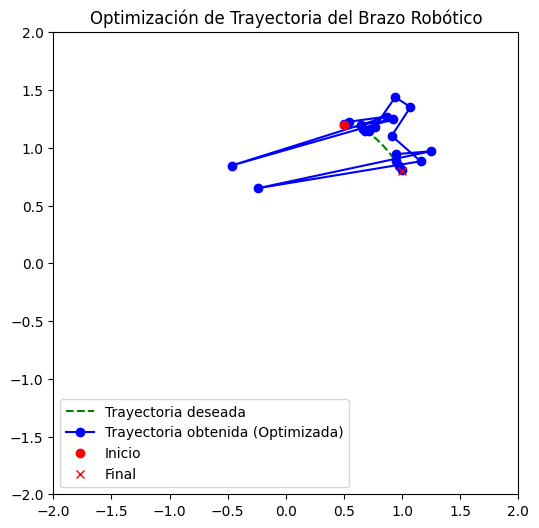

(np.float64(0.3167378164325243),
 np.float64(1.7185635510657185),
 np.float64(-0.19675958396550708),
 np.float64(1.7475373438551665))

In [1]:
# **Reejecutar código tras el reinicio del entorno**

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Definimos la trayectoria deseada (ejemplo: parábola)**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

# Trayectoria deseada: parábola en el espacio (x, y)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Función de cinemática directa**
def forward_kinematics(theta1, theta2):
    x = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    y = L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    return x, y

# **Función objetivo: Minimizar el error de trayectoria + suavidad**
def objective_function(thetas, idx):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    error_trayectoria = np.sum((forward_kinematics(theta1_seq[idx], theta2_seq[idx])[0] - x_deseado[idx])**2 +
                               (forward_kinematics(theta1_seq[idx], theta2_seq[idx])[1] - y_deseado[idx])**2)
    
    # Penalización por movimientos bruscos (diferencias entre ángulos consecutivos)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    
    return error_trayectoria + 0.1 * suavidad  # Ponderamos la suavidad

# **Optimización de trayectoria**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)  # Inicialización aleatoria

# Restricciones: límites en los ángulos
bounds = [(-np.pi, np.pi)] * (2*T)

# Optimizamos cada instante de la trayectoria
theta_opt_result = minimize(objective_function, theta_initial, args=(np.arange(T)), bounds=bounds, method='SLSQP')

# Extraer ángulos optimizados
theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Visualización de la trayectoria**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada")

# Dibujar la trayectoria obtenida
x_opt, y_opt = np.zeros(T), np.zeros(T)
for i in range(T):
    x_opt[i], y_opt[i] = forward_kinematics(theta1_opt[i], theta2_opt[i])
ax.plot(x_opt, y_opt, 'bo-', label="Trayectoria obtenida (Optimizada)")

# Dibujar el punto inicial y final
ax.plot(x_deseado[0], y_deseado[0], 'ro', label="Inicio")
ax.plot(x_deseado[-1], y_deseado[-1], 'rx', label="Final")

ax.legend()
ax.set_title("Optimización de Trayectoria del Brazo Robótico")
plt.show()

# Mostrar valores de los ángulos optimizados en el primer y último punto
theta1_opt[0], theta2_opt[0], theta1_opt[-1], theta2_opt[-1]
